<a href="https://colab.research.google.com/github/RaisingEntropy/evolutionary_computation/blob/master/neuroevolution/Neuroevolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/d9w/evolution/raw/master/imgs/logo.png" width="20%" align="right" style="margin:0px 20px">


# Evolutionary Algorithms

## Evolving Neural Networks with ES

<a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" align="left" src="https://i.creativecommons.org/l/by-sa/4.0/80x15.png" /></a>&nbsp;| Dennis G. Wilson, Yuri Lavinas, Paul Templier | <a href="https://d9w.github.io/evolution/">https://d9w.github.io/evolution/</a>

In order to visualize the environment in this notebook, you will need to install the following:

In [1]:
!apt-get install -y xvfb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [2]:
!pip install cma swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.1 MB/s eta 0:00:00


In [3]:
 !pip install pyvirtualdisplay gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.2 MB/s eta 0:00:00


In [28]:
#!pip install torch

# <a name="neuroevolution"></a> ES for Neuroevolution

Evolutionary strategies are intended for continuous optimization and can easily be applied to the optimization of neural network parameters, or *neuroevolution*.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.multiprocessing as mp
import numpy as np
import gymnasium as gym
import time

In [45]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_shape, n_actions):
        super(NeuralNetwork, self).__init__()
        self.l1 = nn.Linear(input_shape, 32)
        self.l2 = nn.Linear(32, 32)
        self.l3 = nn.Linear(32, 32)
        self.lout = nn.Linear(32, n_actions)

    def forward(self, x):
        x = F.relu(self.l1(x.float()))
        x = F.relu(self.l2(x))
        x = F.relu(self.l3(x))
        return self.lout(x)

    def get_params(self):
        p = np.empty((0,))
        for n in self.parameters():
            p = np.append(p, n.flatten().cpu().detach().numpy())
        return p

    def set_params(self, x):
        start = 0
        for p in self.parameters():
            e = start + np.prod(p.shape)
            p.data = torch.FloatTensor(x[start:e]).reshape(p.shape)
            start = e

We'll add some visualization functionality to have the environment render directly in the notebook.

In [46]:
from pyvirtualdisplay import Display
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
pydisplay = Display(visible=0, size=(1400, 900))
pydisplay.start()
plt.ion();

Following the framework of evolutionary policy search, we will optimize a neural network representing a policy and maximize the total reward over a single episode using this policy.

In [47]:
def evaluate(ann, env, visul=True):
    obs, info = env.reset(seed=0)

    # Create the figure and axis only once before starting
    if visul:
        plt.figure(figsize=(8, 6))
        img = plt.imshow(env.render())
        plt.axis('off')
        plt.tight_layout()

    total_reward = 0
    while True:
        # Output of the neural net
        net_output = ann(torch.tensor(obs))
        # the action is the value clipped returned by the nn
        action = net_output.data.cpu().numpy().argmax()
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

        if visul:
            img.set_data(env.render())
            display.display(plt.gcf())
            display.clear_output(wait=True)
            # Small sleep to allow rendering to complete properly
            time.sleep(0.01)

        if done:
            break

    if visul:
        plt.close()

    return total_reward

In [48]:
import base64
def evaluate_video(ann, env, visul=True):
    obs, info = env.reset(seed=0)
    total_reward = 0

    if visul:
        frames = []
        frames.append(env.render())

    while True:
        net_output = ann(torch.tensor(obs))
        action = net_output.data.cpu().numpy().argmax()
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

        if visul:
            frames.append(env.render())

        if done:
            break

    if visul:
        # Convert frames to mp4 video
        from moviepy.editor import ImageSequenceClip
        from IPython.display import HTML

        clip = ImageSequenceClip(frames, fps=20)
        video_file = 'lunar_lander.mp4'
        clip.write_videofile(video_file, fps=20)

        # Display the video
        with open(video_file, 'rb') as f:
            video_data = f.read()

        display.display(HTML("""
        <video width="640" height="480" controls autoplay>
            <source src="data:video/mp4;base64,{0}" type="video/mp4">
        </video>
        """.format(base64.b64encode(video_data).decode())))

    return total_reward

We've configured this for discrete action spaces. We can see a random neural network on different environments like `CartPole-v0`, `MountainCar-v0`, and `LunarLander-v2`.

In [49]:
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)

In [50]:
evaluate_video(ann, env, visul=True)

Moviepy - Building video lunar_lander.mp4.
Moviepy - Writing video lunar_lander.mp4



Moviepy - Done !
Moviepy - video ready lunar_lander.mp4


np.float64(-317.732650637907)

In order to evolve the parameters of this neural network, we will modify the parameters of the network using `set_params` with the genes of the new individual. In the evolutionary literature, this is referred to as a *direct encoding* as the neural network parameters are directly encoded in the genome.

In [51]:
def fitness(x, ann, env, visul=False):
    ann.set_params(x)
    return -evaluate(ann, env, visul=visul)

In [52]:
p = ann.get_params()
np.shape(p)

(2532,)

We can first observe a random individual $x$.

In [53]:
x = np.random.rand(len(p))
-fitness(x, ann, env, visul=True)

np.float64(-327.49826784486834)

Let's try optimizing the policy using the simple $(\mu, \lambda)$ ES we proposed.

In [54]:
def mu_lambda(x, fitness, gens=200, lam=10, alpha=0.2, verbose=False):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in range(gens):
        N = np.random.normal(size=(lam, len(x)))
        F = np.zeros(lam)
        for i in range(lam):
            ind = x + N[i, :]
            F[i] = fitness(ind)
            if F[i] < f_best:
                f_best = F[i]
                x_best = ind
                if verbose:
                    print(g, " ", f_best)
        fits[g] = f_best
        mu_f = np.mean(F)
        std_f = np.std(F)
        A = F
        if std_f != 0:
            A = (F - mu_f) / std_f
        x = x - alpha * np.dot(A, N) / lam
    return fits, x_best

In [55]:
np.random.seed(654)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
x = np.random.randn(len(ann.get_params()))
f = lambda x : fitness(x, ann, env)
fits, x = mu_lambda(x, f, gens=50, lam=40, alpha=0.1, verbose=True)

0   113.59310254148751
0   101.96701820160216
2   54.773071505715976
4   -6.48751263949346
5   -18.342269773537524
5   -53.925152936577604
15   -54.7672537730958
48   -56.8757439080006


In [56]:
fits

array([101.9670182 , 101.9670182 ,  54.77307151,  54.77307151,
        -6.48751264, -53.92515294, -53.92515294, -53.92515294,
       -53.92515294, -53.92515294, -53.92515294, -53.92515294,
       -53.92515294, -53.92515294, -53.92515294, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -54.76725377, -54.76725377, -54.76725377, -54.76725377,
       -56.87574391, -56.87574391])

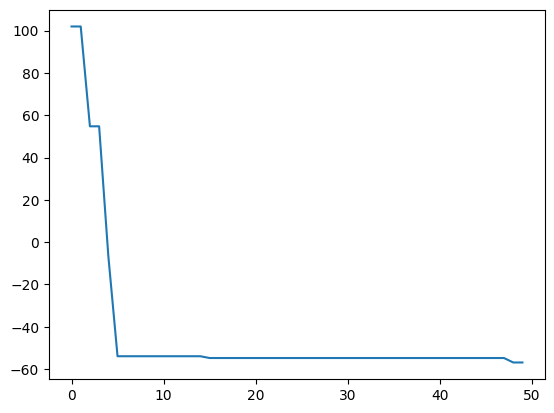

In [57]:
plt.plot(fits);

In [58]:
-fitness(x, ann, env, visul=True)

np.float64(56.8757439080006)

# CMA-ES for Neuroevolution

We will now use CMA-ES for the Lunar Lander problem

In [66]:
import cma
np.random.seed(123)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
es = cma.CMAEvolutionStrategy(len(ann.get_params()) * [0], 0.1, {'seed': 123})

(13_w,27)-aCMA-ES (mu_w=7.8,w_1=22%) in dimension 2532 (seed=123, Mon Apr 13 13:35:13 2026)


In [69]:
for i in range(200):
    solutions = np.array(es.ask())
    fits = [fitness(x, ann, env) for x in solutions]
    es.tell(solutions, fits)
    es.disp()

  109   2943 -2.166866173318206e+01 1.0e+00 8.31e-02  8e-02  8e-02 2:06.4
  120   3240 -7.222987646278756e+01 1.0e+00 8.23e-02  8e-02  8e-02 2:32.2
  121   3267 -4.559039633988567e+01 1.0e+00 8.22e-02  8e-02  8e-02 21:18.6
  131   3537 -2.119722947936333e+02 1.0e+00 8.15e-02  8e-02  8e-02 21:39.2
  150   4050 -2.653934910272216e+02 1.0e+00 8.04e-02  8e-02  8e-02 22:00.3
  157   4239 -8.816375113049079e+01 1.0e+00 8.00e-02  8e-02  8e-02 23:47.5
  168   4536 -7.969820750802896e+01 1.0e+00 7.95e-02  8e-02  8e-02 24:10.9
  170   4590 -2.714602994196306e+01 1.0e+00 7.95e-02  8e-02  8e-02 24:57.6
  194   5238 -6.709472587864479e+01 1.0e+00 7.86e-02  8e-02  8e-02 25:22.7
  200   5400 -6.709472587864479e+01 1.0e+00 7.84e-02  8e-02  8e-02 25:34.6
  229   6183 -6.709472587864479e+01 1.0e+00 7.75e-02  8e-02  8e-02 26:02.0
  253   6831 -6.709472587864479e+01 1.0e+00 7.70e-02  8e-02  8e-02 26:30.2
  284   7668 -2.827972966257990e+02 1.0e+00 7.64e-02  8e-02  8e-02 27:00.3
  300   8100 -2.95683913750

In [70]:
x = es.result[0]
-fitness(x, ann, env, visul=True)

np.float64(304.9415148066072)

The results on LunarLander clearly show the benefits of CMA-ES; we have found a reasonable policy in a small number of generations. Applying CMA-ES to larger neural networks remains an open challenge, however, due to the vast number of parameters in ANNs. Specifically, CMA-ES calculates the covariance of all parameters, which is $O(n^2)$.

In [71]:
np.shape(es.sm.C)

(2532, 2532)

<div class="alert alert-success">
    <h3>Exercise 1</h3>
    
The network used has 2 layers of 32 neurons each. Try changing this and noticing the impact on the number of total parameters for CMA-ES. How large of a network can CMA-ES optimize?
</div>

<div class="alert alert-success">
    <h3>Exercise 2</h3>
    
Compare the $(1+\lambda)$ ES, $(\mu,\lambda)$ ES, and CMA-ES algorithms on Lunar Lander. Is one significantly better than the others, consistently across different initializations?
</div>